In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
!pip install underthesea


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


### **Import thư viện và kết nối với Source code**

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Khai báo đường dẫn để Notebook có thể import được thư mục src/
import sys
import os
sys.path.append(os.path.abspath('../')) 

from src.data_loader import load_data
from src.preprocess import clean_text
from src.features import run_feature_pipeline

### **Kích hoạt Pipeline trích xuất đặc trưng**

In [5]:
print("⏳ Đang gọi lại Pipeline từ hệ thống...")
df = load_data('../data/raw/labeled_comments.xlsx')
df['clean_text'] = df['Text'].apply(clean_text)

# Sử dụng chính hàm run_feature_pipeline nhóm đã viết
features = run_feature_pipeline(df)

X_train, X_test = features["X_train_tfidf"], features["X_test_tfidf"]
y_train, y_test = features["y_train"], features["y_test"]

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

⏳ Đang gọi lại Pipeline từ hệ thống...
⏳ Đang tải dữ liệu từ: ../data/raw/labeled_comments.xlsx...
✅ Tải dữ liệu hoàn tất! Thu thập được 1242.
Kích thước tập Train: (993, 3662)
Kích thước tập Test: (249, 3662)


### **Mô hình Multinomial Naive Bayes**

In [6]:
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

print("=== BÁO CÁO: MULTINOMIAL NAIVE BAYES ===")
print(f"Accuracy: {accuracy_score(y_test, nb_preds):.4f}\n")
print(classification_report(y_test, nb_preds))

=== BÁO CÁO: MULTINOMIAL NAIVE BAYES ===
Accuracy: 0.7992

              precision    recall  f1-score   support

    negative       0.91      0.52      0.66        94
    positive       0.77      0.97      0.86       155

    accuracy                           0.80       249
   macro avg       0.84      0.74      0.76       249
weighted avg       0.82      0.80      0.78       249



### **Mô hình Logistic Regression (Có cân bằng nhãn)**

In [7]:
# class_weight='balanced' sẽ tự động xử lý độ lệch dữ liệu tương đương với SMOTE
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("=== BÁO CÁO: LOGISTIC REGRESSION ===")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}\n")
print(classification_report(y_test, lr_preds))

=== BÁO CÁO: LOGISTIC REGRESSION ===
Accuracy: 0.8795

              precision    recall  f1-score   support

    negative       0.83      0.85      0.84        94
    positive       0.91      0.90      0.90       155

    accuracy                           0.88       249
   macro avg       0.87      0.87      0.87       249
weighted avg       0.88      0.88      0.88       249



### **Ma trận nhầm lẫn (Confusion Matrix) để so sánh trực quan**

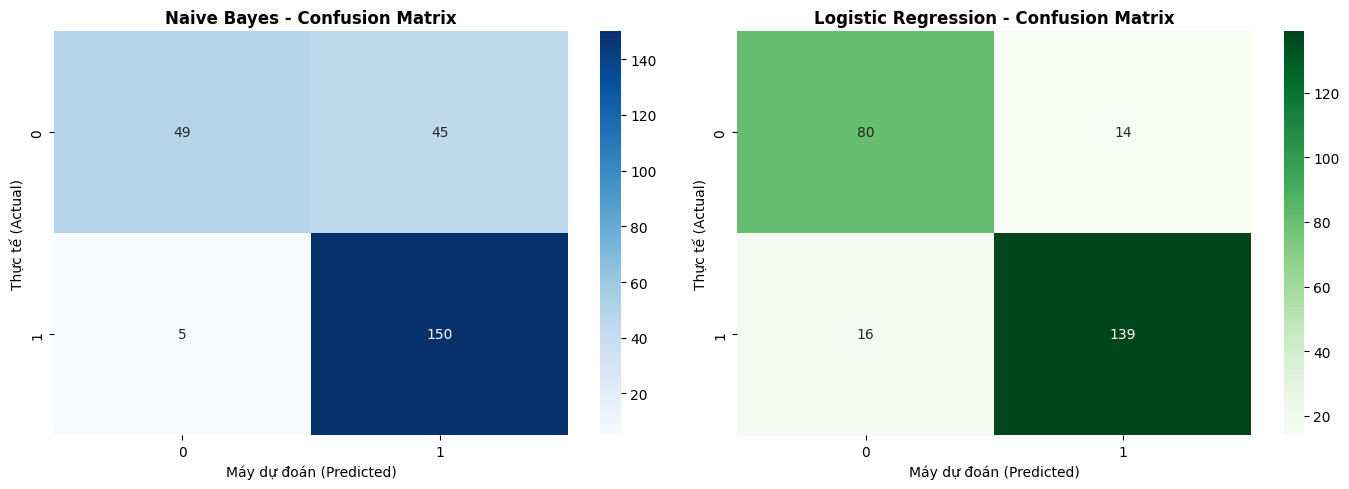

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vẽ bảng cho Naive Bayes
sns.heatmap(confusion_matrix(y_test, nb_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Naive Bayes - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Máy dự đoán (Predicted)')
axes[0].set_ylabel('Thực tế (Actual)')

# Vẽ bảng cho Logistic Regression
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Logistic Regression - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Máy dự đoán (Predicted)')
axes[1].set_ylabel('Thực tế (Actual)')

plt.tight_layout()
plt.show()